<a href="https://colab.research.google.com/github/mdzubayereashraf/Ostad-AI-Engineering-Course-Assignments/blob/main/Assignmen_No_13(Deep_Learning_Project_Handwritten_Digit_Classifier_(MNIST)).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Deep Learning Project: Handwritten Digit Classifier**

## **Objective:**

The goal of this project is to build a deep learning model
that can classify handwritten digits from 0 to 9 using the
MNIST dataset.

The project includes:
- Data preprocessing
- Neural network construction
- Batch normalization
- Dropout regularization
- Model training
- Accuracy and loss visualization
- Test-set evaluation

### **Import the Necessary Libraries**

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout

### **Part 1: Dataset Loading**

In [3]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)

print("Test images:", x_test.shape)
print("Test labels:", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training images: (60000, 28, 28)
Training labels: (60000,)
Test images: (10000, 28, 28)
Test labels: (10000,)


### **Sample Images**

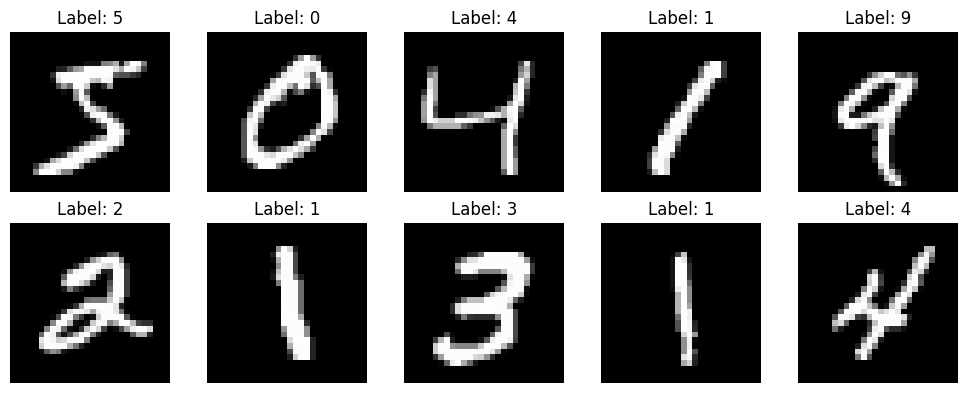

In [4]:
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

### **Part 2: Data Preprocessing**
Normalization

In [5]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Minimum pixel value:", x_train.min())
print("Maximum pixel value:", x_train.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


### Flatten the Images

In [6]:
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

print("Training shape:", x_train.shape)
print("Test shape:", x_test.shape)

Training shape: (60000, 784)
Test shape: (10000, 784)


### **Part 3: Model Architecture**

The model contains three hidden layers with batch normalization
and dropout regularization.

In [7]:
model = Sequential([

    # First hidden layer
    Dense(256, activation='relu', input_shape=(784,)),
    BatchNormalization(),
    Dropout(0.3),

    # Second hidden layer
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    # Third hidden layer
    Dense(64, activation='relu'),
    Dropout(0.2),

    # Output layer
    Dense(10, activation='softmax')
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### **View Model Summary**

In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 244,298 (954.29 KB)

 Trainable params: 243,530 (951.29 KB)

 Non-trainable params: 768 (3.00 KB)

### **Part 4: Compile the Model**

In [9]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

### **Train the Model**

In [12]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9840 - loss: 0.0505 - val_accuracy: 0.9797 - val_loss: 0.0806
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9847 - loss: 0.0481 - val_accuracy: 0.9796 - val_loss: 0.0802
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9854 - loss: 0.0453 - val_accuracy: 0.9797 - val_loss: 0.0838
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9860 - loss: 0.0457 - val_accuracy: 0.9797 - val_loss: 0.0799
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9875 - loss: 0.0411 - val_accuracy: 0.9812 - val_loss: 0.0808
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9872 - loss: 0.0394 - val_accuracy: 0.9811 - val_loss: 0.0757
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9876 - loss: 0.0387 - val_accuracy: 0.9813 - val_loss: 0.0775
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9870 - loss: 0.0410 - val_accuracy: 0.

### **Part 5: Training and Validation Accuracy**

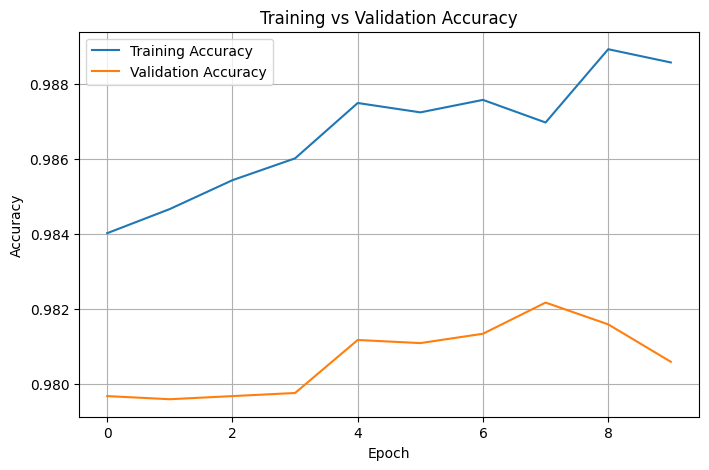

In [13]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')

plt.legend()
plt.grid(True)

plt.show()

### **Interpretation**

The training accuracy generally increases as the model learns
from the training data. The validation accuracy shows how well
the model performs on unseen validation data.

If the training accuracy becomes much higher than the validation
accuracy, it may indicate overfitting. Dropout and batch
normalization are used to help improve generalization.

### **Training and Validation Loss**

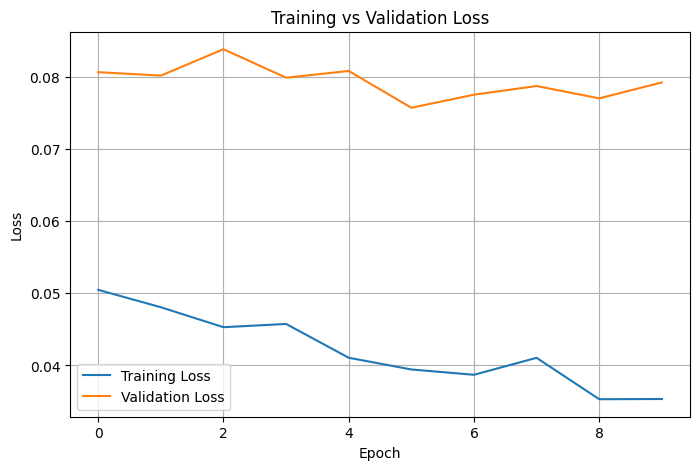

In [14]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')

plt.legend()
plt.grid(True)

plt.show()

###**Interpretation**

Training loss generally decreases as the model learns.
Validation loss helps us monitor the model's performance on
unseen validation data. A large gap between training and
validation loss can be a sign of overfitting.

### **Part 6: Model Evaluation**

In [15]:
test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Test Loss: 0.0648
Test Accuracy: 0.9841
Test Accuracy: 98.41%


### **Make Predictions**

In [16]:
predictions = model.predict(x_test)

predicted_labels = np.argmax(predictions, axis=1)

print("Predicted:", predicted_labels[:10])
print("Actual:   ", y_test[:10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Predicted: [7 2 1 0 4 1 4 9 6 9]
Actual:    [7 2 1 0 4 1 4 9 5 9]


### **Visualize Predictions**

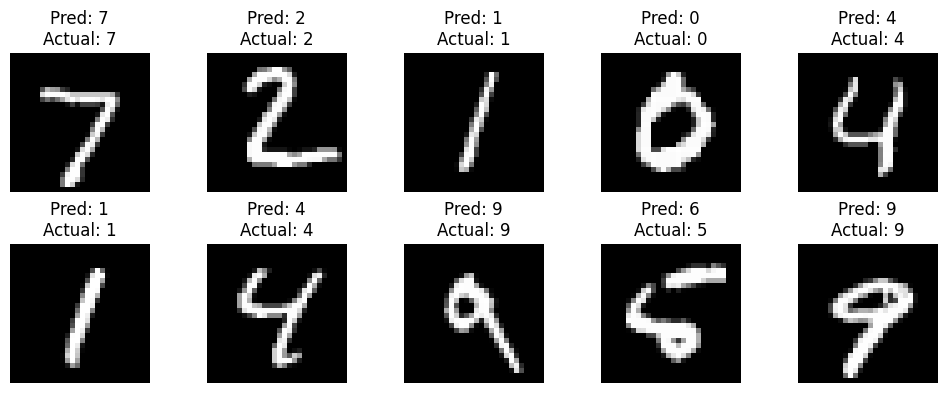

In [17]:
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)

    image = x_test[i].reshape(28, 28)

    plt.imshow(image, cmap='gray')
    plt.title(
        f"Pred: {predicted_labels[i]}\nActual: {y_test[i]}"
    )
    plt.axis('off')

plt.tight_layout()
plt.show()